# MgAl$_2$O$_4$ spinel: testing the disordered EFG point-charge calculation

This notebook validates the Monte Carlo disorder support added to `pyEFGPointCharge`.

## Background

### The point-charge EFG calculation

The electric field gradient (EFG) tensor at a probe nucleus is computed as a lattice sum of point-charge contributions:

$$V_{\alpha\beta} = \frac{1}{4\pi\epsilon_0}\sum_i q_i \frac{3r_{i\alpha}r_{i\beta} - r_i^2\delta_{\alpha\beta}}{r_i^5}$$

where $q_i$ is the charge at site $i$, $\vec{r}_i$ is the displacement from the probe to site $i$, and the sum runs over all charge sites within a sphere of chosen radius.

### Site disorder in MgAl$_2$O$_4$ spinel

MgAl$_2$O$_4$ has the cubic spinel structure (space group $Fd\bar{3}m$, No. 227). In the ideal "normal" spinel:
- **8a (tetrahedral) sites**: occupied by Mg$^{2+}$
- **16d (octahedral) sites**: occupied by Al$^{3+}$
- **32e sites**: occupied by O$^{2-}$

In practice, a fraction $i$ of Mg$^{2+}$ and Al$^{3+}$ swap positions ("cation inversion"). This creates **substitutional disorder**:
- 8a sites: $(1-i)$ Mg + $i$ Al
- 16d sites: $(1-i/2)$ Al + $(i/2)$ Mg

The CIF used here (Redfern et al. 1999, COD 9002084, T = 673 K) has $i = 0.155$.

### Monte Carlo sampling approach

Rather than using a single "average" charge at each disordered site, we generate many random configurations:
1. For each Monte Carlo step, each disordered site is randomly assigned a species (Mg or Al) according to its occupancy probability.
2. The EFG is computed for that configuration.
3. The result is a *distribution* of EFG parameters ($V_{zz}$, $\eta$, $\nu_Q$) that reflects the local structural disorder.

Two sampling modes are supported:
- **Independent**: each site is sampled independently from its CIF occupancy.
- **Correlated (disorder groups)**: sets of sites are sampled together as a unit, enforcing physical correlations (e.g., when Al inverts from octahedral to tetrahedral, Mg must simultaneously move the other way).

### $^{27}$Al NMR reference values

| Site | $C_Q$ (MHz) | $\eta$ | Reference |
|------|-------------|--------|----------|
| Tetrahedral Al (8a, inverted) | ~1.6 | ~0 | Millard et al. 1992 |
| Octahedral Al (16d, normal) | ~3.3–3.7 | ~0 | Millard et al. 1992; Kashii et al. 1999 |
| Octahedral Al near inverted neighbor | ~5–7 (broad) | 0–0.4 | Kashii et al. 1999 |

---
## Imports

In [1]:
import sys, os
import numpy as np
import time
import matplotlib.pyplot as plt

# add parent directory so we can import pyEFGPointCharge
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import pyEFGPointCharge
from pymatgen.core import Structure

%matplotlib inline

---
## Test 1: backwards compatibility with ordered $\alpha$-Al$_2$O$_3$

The refactored `calc_EFG_point_charge` should produce **identical** results for ordered structures (no disorder detected $\Rightarrow$ single-pass calculation, no Monte Carlo). The `*_samples` result fields should all be `None`.

Reference values from the original code (see `EFG_point_charge_aAlO2/aAl2O3_EFG_point_charge_calc_2021-10-18.ipynb`):

| Quantity | Expected value |
|----------|---------------|
| $V_{xx}$ | $2.88260527 \times 10^{20}$ V/m$^2$ |
| $V_{yy}$ | $1.14735309 \times 10^{21}$ V/m$^2$ |
| $V_{zz}$ | $-1.43561361 \times 10^{21}$ V/m$^2$ |
| $\eta$ | 0.598 |
| $\nu_Q$ | 0.1295 MHz |

In [2]:
# load the ordered aAl2O3 structure
cif_aAl2O3 = os.path.join('..', 'EFG_point_charge_aAlO2',
                           'Ishizawa_1980_aAl2O3_300K_EntryWithCollCode10425.cif')
structure_aAl2O3 = Structure.from_file(cif_aAl2O3)
print(structure_aAl2O3)

Full Formula (Al12 O18)
Reduced Formula: Al2O3
abc   :   4.754000   4.754000  12.990000
angles:  90.000000  90.000000 120.000000
Sites (30)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Al3+  0         0         0.14772
  1  Al3+  0         0         0.64772
  2  Al3+  0         0         0.85228
  3  Al3+  0         0         0.35228
  4  Al3+  0.666667  0.333333  0.481053
  5  Al3+  0.666667  0.333333  0.981053
  6  Al3+  0.666667  0.333333  0.185613
  7  Al3+  0.666667  0.333333  0.685613
  8  Al3+  0.333333  0.666667  0.814387
  9  Al3+  0.333333  0.666667  0.314387
 10  Al3+  0.333333  0.666667  0.518947
 11  Al3+  0.333333  0.666667  0.018947
 12  O2-   0.3064    0         0.25
 13  O2-   0.6936    0.6936    0.25
 14  O2-   0         0.3064    0.25
 15  O2-   0.3064    0.3064    0.75
 16  O2-   0         0.6936    0.75
 17  O2-   0.6936    0         0.75
 18  O2-   0.973067  0.333333  0.583333
 19  O2-   0.360267  0.026933  0.583333
 20  O2-

In [3]:
# run the EFG calculation with the same parameters as the original example
input_pars = pyEFGPointCharge.input_parameters()
input_pars.cif_file_name = cif_aAl2O3
input_pars.sphere_radius = 3
input_pars.probe_site_index = 12
input_pars.delete_plotting_arrays = False
input_pars.manual_nuclear_quad_moment = -0.0265
input_pars.manual_nuclear_spin = 5/2
input_pars.charge_site_indices = [i for i in range(30)]
input_pars.first_cell_charges = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
                                 -2,-2,-2,-2,-2,-2,-2,-2,-2,
                                 -2,-2,-2,-2,-2,-2,-2,-2,-2]

results_ordered = pyEFGPointCharge.results()
t0 = time.time()
pyEFGPointCharge.calc_EFG_point_charge(input_pars, results_ordered)
print(f'calc took {time.time()-t0:.3f} s')

print(f'\nV_aa (V/m^2) = {results_ordered.V_aa}')
print(f'eta          = {results_ordered.eta:.4f}')
print(f'nu_Q (MHz)   = {results_ordered.nu_Q_MHz:.6f}')
print(f'\nV_aa_samples is None: {results_ordered.V_aa_samples is None}')
print(f'eta_samples  is None: {results_ordered.eta_samples is None}')
print(f'nu_Q_MHz_samples is None: {results_ordered.nu_Q_MHz_samples is None}')

# verify against expected values
expected_V_aa = np.array([2.88260527e+20, 1.14735309e+21, -1.43561361e+21])
assert np.allclose(results_ordered.V_aa, expected_V_aa, rtol=1e-6), 'V_aa mismatch!'
assert np.isclose(results_ordered.eta, 0.5984148884763552, rtol=1e-6), 'eta mismatch!'
assert results_ordered.V_aa_samples is None, 'V_aa_samples should be None for ordered!'
assert results_ordered.eta_samples is None, 'eta_samples should be None for ordered!'
print('\nAll assertions passed.')

calc took 0.107 s

V_aa (V/m^2) = [ 2.88260527e+20  1.14735309e+21 -1.43561361e+21]
eta          = 0.5984
nu_Q (MHz)   = 0.129487

V_aa_samples is None: True
eta_samples  is None: True
nu_Q_MHz_samples is None: True

All assertions passed.


---
## Test 2: structure loading and site identification for MgAl$_2$O$_4$

The disordered CIF (COD 9002084) encodes two atom types at each cation site with partial occupancy. Pymatgen reads these as single `PeriodicSite` objects with mixed-species `Composition`, marking them as `is_ordered = False`.

Expected site layout for the conventional cell ($Z=8$, 56 atoms):

| Index range | Wyckoff | Coordination | Species | Occupancy | is_ordered |
|-------------|---------|--------------|---------|-----------|------------|
| 0–7 | 8a | Tetrahedral | Mg$_{0.845}$Al$_{0.155}$ | < 1 each | False |
| 8–23 | 16d | Octahedral | Al$_{0.9225}$Mg$_{0.0775}$ | < 1 each | False |
| 24–55 | 32e | — | O | 1.0 | True |

In [4]:
cif_spinel = 'Redfern_1999_MgAl2O4_673K_COD9002084.cif'
structure_spinel = Structure.from_file(cif_spinel)
print(structure_spinel)
print(f'\nTotal sites: {len(structure_spinel)}')

Full Formula (Mg8.0 Al16.0 O32)
Reduced Formula: MgAl2O4
abc   :   8.110090   8.110090   8.110090
angles:  90.000000  90.000000  90.000000
Sites (56)
  #  SP                        a        b        c
---  ------------------  -------  -------  -------
  0  Mg:0.845, Al:0.155  0.125    0.125    0.125
  1  Mg:0.845, Al:0.155  0.125    0.625    0.625
  2  Mg:0.845, Al:0.155  0.625    0.125    0.625
  3  Mg:0.845, Al:0.155  0.625    0.625    0.125
  4  Mg:0.845, Al:0.155  0.875    0.375    0.375
  5  Mg:0.845, Al:0.155  0.875    0.875    0.875
  6  Mg:0.845, Al:0.155  0.375    0.375    0.875
  7  Mg:0.845, Al:0.155  0.375    0.875    0.375
  8  Mg:0.077, Al:0.922  0.5      0.5      0.5
  9  Mg:0.077, Al:0.922  0.5      0        0
 10  Mg:0.077, Al:0.922  0        0.5      0
 11  Mg:0.077, Al:0.922  0        0        0.5
 12  Mg:0.077, Al:0.922  0.25     0        0.75
 13  Mg:0.077, Al:0.922  0.25     0.5      0.25
 14  Mg:0.077, Al:0.922  0.75     0        0.25
 15  Mg:0.077, Al:0.922  0.7

In [5]:
# classify sites by species and disorder status
print(f'{"Index":>5}  {"Species":>30}  {"Ordered?":>8}  Fractional coordinates')
print('-' * 90)
for i, site in enumerate(structure_spinel):
    print(f'{i:>5}  {str(site.species):>30}  {str(site.is_ordered):>8}  '
          f'{site.frac_coords}')

# verify expected layout
n_disordered = sum(1 for s in structure_spinel if not s.is_ordered)
n_ordered = sum(1 for s in structure_spinel if s.is_ordered)
print(f'\nDisordered sites: {n_disordered} (expected 24 = 8 tet + 16 oct)')
print(f'Ordered sites:    {n_ordered} (expected 32 oxygens)')

assert len(structure_spinel) == 56, f'Expected 56 sites, got {len(structure_spinel)}'
assert n_disordered == 24
assert n_ordered == 32
# check that sites 0-7 are tetrahedral (disordered)
for i in range(8):
    assert not structure_spinel[i].is_ordered, f'Site {i} should be disordered'
# check that sites 8-23 are octahedral (disordered)
for i in range(8, 24):
    assert not structure_spinel[i].is_ordered, f'Site {i} should be disordered'
# check that sites 24-55 are O (ordered)
for i in range(24, 56):
    assert structure_spinel[i].is_ordered, f'Site {i} should be ordered'
print('\nAll assertions passed.')

Index                         Species  Ordered?  Fractional coordinates
------------------------------------------------------------------------------------------
    0                 Mg0.845 Al0.155     False  [0.125 0.125 0.125]
    1                 Mg0.845 Al0.155     False  [0.125 0.625 0.625]
    2                 Mg0.845 Al0.155     False  [0.625 0.125 0.625]
    3                 Mg0.845 Al0.155     False  [0.625 0.625 0.125]
    4                 Mg0.845 Al0.155     False  [0.875 0.375 0.375]
    5                 Mg0.845 Al0.155     False  [0.875 0.875 0.875]
    6                 Mg0.845 Al0.155     False  [0.375 0.375 0.875]
    7                 Mg0.845 Al0.155     False  [0.375 0.875 0.375]
    8               Al0.9225 Mg0.0775     False  [0.5 0.5 0.5]
    9               Al0.9225 Mg0.0775     False  [0.5 0.  0. ]
   10               Al0.9225 Mg0.0775     False  [0.  0.5 0. ]
   11               Al0.9225 Mg0.0775     False  [0.  0.  0.5]
   12               Al0.9225 Mg0.

---
## Helper: common setup for MgAl$_2$O$_4$ calculations

Define site indices, charges, and a factory function so the remaining tests don't repeat boilerplate.

In [6]:
# site index ranges
n_tet, n_oct, n_O = 8, 16, 32
tet_indices = list(range(0, n_tet))
oct_indices = list(range(n_tet, n_tet + n_oct))
O_indices   = list(range(n_tet + n_oct, n_tet + n_oct + n_O))
all_charge_indices = tet_indices + oct_indices + O_indices

# charge specification
#   disordered sites: dict keyed by element symbol
#   ordered sites: scalar
base_charges = [None] * (n_tet + n_oct + n_O)
for i in tet_indices:
    base_charges[i] = {'Mg': +2.0, 'Al': +3.0}
for i in oct_indices:
    base_charges[i] = {'Al': +3.0, 'Mg': +2.0}
for i in O_indices:
    base_charges[i] = -2.0


def make_input(sphere_radius=10.0, probe_site_index=8,
               n_mc=500, seed=42, groups=None):
    """Create an input_parameters object for MgAl2O4 with common defaults."""
    ip = pyEFGPointCharge.input_parameters()
    ip.cif_file_name = cif_spinel
    ip.sphere_radius = sphere_radius
    ip.probe_site_index = probe_site_index
    ip.charge_site_indices = all_charge_indices
    ip.first_cell_charges = list(base_charges)
    ip.probe_nucleus = '27Al'
    ip.n_monte_carlo_samples = n_mc
    ip.random_seed = seed
    ip.delete_plotting_arrays = True
    if groups is not None:
        ip.disorder_groups = groups
    return ip


print('Helper defined. Probe nucleus: 27Al (I = 5/2, Q = 0.1466 barns)')

Helper defined. Probe nucleus: 27Al (I = 5/2, Q = 0.1466 barns)


---
## Test 3: independent disorder — basic function

Run the MC calculation with independently sampled sites. Verify:
1. Output array shapes are `(n_mc, 3)`, `(n_mc,)`, `(n_mc,)`.
2. The scalar result fields (`V_aa`, `eta`, `nu_Q_MHz`) equal the mean of their respective sample arrays.

In [7]:
ip = make_input(n_mc=500, seed=42)
results_indep = pyEFGPointCharge.results()

t0 = time.time()
pyEFGPointCharge.calc_EFG_point_charge(ip, results_indep)
print(f'calc took {time.time()-t0:.2f} s for {ip.n_monte_carlo_samples} MC samples')

# check shapes
print(f'\nV_aa_samples.shape     = {results_indep.V_aa_samples.shape}')
print(f'eta_samples.shape      = {results_indep.eta_samples.shape}')
print(f'nu_Q_MHz_samples.shape = {results_indep.nu_Q_MHz_samples.shape}')

assert results_indep.V_aa_samples.shape == (500, 3)
assert results_indep.eta_samples.shape == (500,)
assert results_indep.nu_Q_MHz_samples.shape == (500,)

# check scalar == mean of samples
assert np.allclose(results_indep.V_aa, np.mean(results_indep.V_aa_samples, axis=0))
assert np.isclose(results_indep.eta, np.mean(results_indep.eta_samples))
assert np.isclose(results_indep.nu_Q_MHz, np.mean(results_indep.nu_Q_MHz_samples))

print(f'\nMean V_aa  = {results_indep.V_aa}')
print(f'Mean eta   = {results_indep.eta:.4f}')
print(f'Mean nu_Q  = {results_indep.nu_Q_MHz:.6f} MHz')
print(f'Mean |nu_Q|= {np.mean(np.abs(results_indep.nu_Q_MHz_samples)):.6f} MHz')
print(f'Std  |nu_Q|= {np.std(np.abs(results_indep.nu_Q_MHz_samples)):.6f} MHz')
print('\nAll assertions passed.')

calc took 4.50 s for 500 MC samples

V_aa_samples.shape     = (500, 3)
eta_samples.shape      = (500,)
nu_Q_MHz_samples.shape = (500,)

Mean V_aa  = [ 4.01008768e+18  8.46497842e+18 -1.24750661e+19]
Mean eta   = 0.5932
Mean nu_Q  = -0.006448 MHz
Mean |nu_Q|= 0.046705 MHz
Std  |nu_Q|= 0.023009 MHz

All assertions passed.


---
## Test 4: independent disorder — physical sanity

Check that the distributions make physical sense:
- $\eta$ should span 0 to 1 (disorder breaks the $D_{3d}$ axial symmetry of the octahedral site).
- $|\nu_Q|$ should show a broad distribution centered away from zero.
- The bare point-charge $|\nu_Q|$ will be much smaller than experimental values (~3.5 MHz) because the model omits electronic shielding and orbital contributions. This is a known limitation.

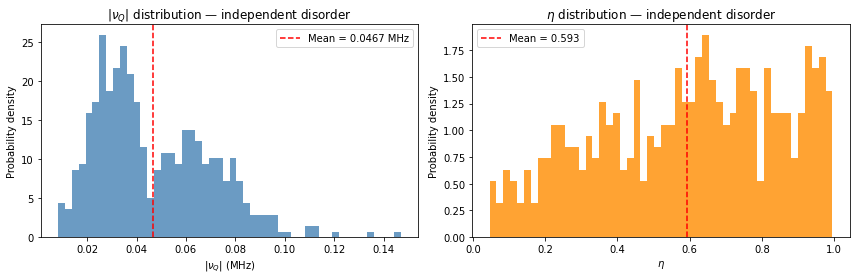

eta range: [0.0463, 0.9950]
  -> spans 0 to ~1 as expected from symmetry breaking
|nu_Q| range: [0.008237, 0.147102] MHz
  -> broad distribution, confirming disorder broadening


In [8]:
nu_Q_abs = np.abs(results_indep.nu_Q_MHz_samples)
eta_vals = results_indep.eta_samples

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# nu_Q distribution
ax = axes[0]
ax.hist(nu_Q_abs, bins=50, density=True, color='steelblue',
        edgecolor='none', alpha=0.8)
ax.axvline(np.mean(nu_Q_abs), color='red', lw=1.5, ls='--',
           label=f'Mean = {np.mean(nu_Q_abs):.4f} MHz')
ax.set_xlabel(r'$|\nu_Q|$ (MHz)')
ax.set_ylabel('Probability density')
ax.set_title(r'$|\nu_Q|$ distribution — independent disorder')
ax.legend()

# eta distribution
ax = axes[1]
ax.hist(eta_vals, bins=50, density=True, color='darkorange',
        edgecolor='none', alpha=0.8)
ax.axvline(np.mean(eta_vals), color='red', lw=1.5, ls='--',
           label=f'Mean = {np.mean(eta_vals):.3f}')
ax.set_xlabel(r'$\eta$')
ax.set_ylabel('Probability density')
ax.set_title(r'$\eta$ distribution — independent disorder')
ax.legend()

plt.tight_layout()
plt.show()

print(f'eta range: [{np.min(eta_vals):.4f}, {np.max(eta_vals):.4f}]')
print(f'  -> spans 0 to ~1 as expected from symmetry breaking')
print(f'|nu_Q| range: [{np.min(nu_Q_abs):.6f}, {np.max(nu_Q_abs):.6f}] MHz')
print(f'  -> broad distribution, confirming disorder broadening')

---
## Test 5: reproducibility

The `random_seed` parameter controls the numpy RNG. We verify:
1. Same seed $\Rightarrow$ identical sample arrays.
2. Different seeds $\Rightarrow$ different sample arrays.
3. `None` seed $\Rightarrow$ non-reproducible (different each run).

In [9]:
# 5a: same seed=42, two runs -> identical
r1 = pyEFGPointCharge.results()
pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=100, seed=42), r1)
r2 = pyEFGPointCharge.results()
pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=100, seed=42), r2)
print(f'seed=42 run1 == seed=42 run2: '
      f'{np.array_equal(r1.nu_Q_MHz_samples, r2.nu_Q_MHz_samples)}')

# 5b: seed=123 -> different from seed=42
r3 = pyEFGPointCharge.results()
pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=100, seed=123), r3)
print(f'seed=42 != seed=123:          '
      f'{not np.array_equal(r1.nu_Q_MHz_samples, r3.nu_Q_MHz_samples)}')

# 5c: seed=None, two runs -> should differ
r4 = pyEFGPointCharge.results()
pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=100, seed=None), r4)
r5 = pyEFGPointCharge.results()
pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=100, seed=None), r5)
print(f'seed=None run1 != run2:       '
      f'{not np.array_equal(r4.nu_Q_MHz_samples, r5.nu_Q_MHz_samples)}')

assert np.array_equal(r1.nu_Q_MHz_samples, r2.nu_Q_MHz_samples)
assert not np.array_equal(r1.nu_Q_MHz_samples, r3.nu_Q_MHz_samples)
assert not np.array_equal(r4.nu_Q_MHz_samples, r5.nu_Q_MHz_samples)
print('\nAll assertions passed.')

seed=42 run1 == seed=42 run2: True
seed=42 != seed=123:          True
seed=None run1 != run2:       True

All assertions passed.


---
## Test 6: convergence with `n_monte_carlo_samples`

As the number of MC samples increases, the mean and standard deviation of $|\nu_Q|$ should stabilize. We expect convergence by ~500–1000 samples for this system.

In [10]:
n_values = [50, 100, 200, 500, 1000, 2000]
means = []
stds = []
times = []

print(f'{"n_mc":>6}  {"mean|nuQ| (MHz)":>16}  {"std|nuQ| (MHz)":>16}  {"time (s)":>10}')
print('-' * 54)

for n in n_values:
    r = pyEFGPointCharge.results()
    t0 = time.time()
    pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=n, seed=42), r)
    dt = time.time() - t0
    m = np.mean(np.abs(r.nu_Q_MHz_samples))
    s = np.std(np.abs(r.nu_Q_MHz_samples))
    means.append(m)
    stds.append(s)
    times.append(dt)
    print(f'{n:>6}  {m:>16.6f}  {s:>16.6f}  {dt:>10.2f}')

  n_mc   mean|nuQ| (MHz)    std|nuQ| (MHz)    time (s)
------------------------------------------------------
    50          0.052655          0.025203        0.56
   100          0.048404          0.026179        1.01
   200          0.047529          0.024662        1.93
   500          0.046705          0.023009        4.39
  1000          0.047274          0.022932        8.78
  2000          0.047391          0.023921       17.05


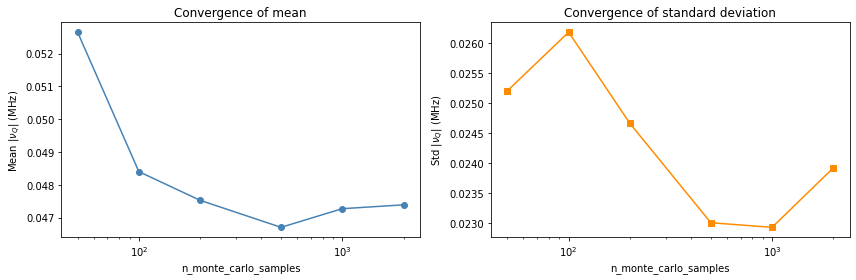


Mean ratio (n=2000 / n=200): 1.015 (expect ~1.0)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_values, means, 'o-', color='steelblue')
axes[0].set_xlabel('n_monte_carlo_samples')
axes[0].set_ylabel(r'Mean $|\nu_Q|$ (MHz)')
axes[0].set_title('Convergence of mean')
axes[0].set_xscale('log')

axes[1].plot(n_values, stds, 's-', color='darkorange')
axes[1].set_xlabel('n_monte_carlo_samples')
axes[1].set_ylabel(r'Std $|\nu_Q|$ (MHz)')
axes[1].set_title('Convergence of standard deviation')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# the mean should be stable to within ~10% between 500 and 2000 samples
ratio = means[-1] / means[-3]  # 2000 vs 200
print(f'\nMean ratio (n=2000 / n=200): {ratio:.3f} (expect ~1.0)')

---
## Test 7: correlated disorder groups

### Physical motivation

Cation inversion is a *correlated* process: when an Al$^{3+}$ moves from an octahedral (16d) site to a tetrahedral (8a) site, it displaces an Mg$^{2+}$ which must go to the vacated octahedral site. The pair swaps as a unit.

With `disorder_groups`, we can model this by defining pairs of sites that are sampled together:

```python
disorder_groups = [
    {
        'site_indices': [tet_idx, oct_idx],
        'configurations': [
            {'species': ['Mg', 'Al'], 'probability': 1 - i},  # normal
            {'species': ['Al', 'Mg'], 'probability': i},       # inverted
        ]
    },
    ...
]
```

We compare correlated vs. independent disorder distributions.

In [12]:
# define correlated pairs: each 8a site paired with one 16d site
inversion_parameter = 0.155

disorder_groups = []
for tet_idx, oct_idx in zip(tet_indices[:8], oct_indices[:8]):
    disorder_groups.append({
        'site_indices': [tet_idx, oct_idx],
        'configurations': [
            {'species': ['Mg', 'Al'], 'probability': 1.0 - inversion_parameter},
            {'species': ['Al', 'Mg'], 'probability': inversion_parameter},
        ]
    })

# the remaining 8 octahedral sites (indices 16-23) are not paired
# and will be sampled independently from their CIF occupancy

ip_corr = make_input(n_mc=500, seed=42, groups=disorder_groups)
results_corr = pyEFGPointCharge.results()

t0 = time.time()
pyEFGPointCharge.calc_EFG_point_charge(ip_corr, results_corr)
print(f'Correlated calc took {time.time()-t0:.2f} s')
print(f'  Mean |nu_Q| = {np.mean(np.abs(results_corr.nu_Q_MHz_samples)):.6f} MHz')
print(f'  Std  |nu_Q| = {np.std(np.abs(results_corr.nu_Q_MHz_samples)):.6f} MHz')
print(f'  Mean eta    = {np.mean(results_corr.eta_samples):.4f}')

Correlated calc took 1.79 s
  Mean |nu_Q| = 0.054095 MHz
  Std  |nu_Q| = 0.028162 MHz
  Mean eta    = 0.5978


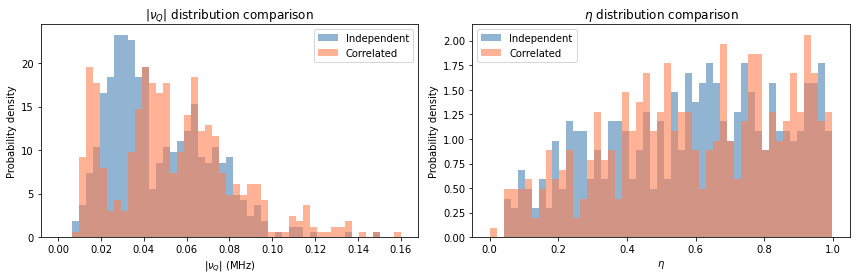

Independent: mean|nu_Q| = 0.046705, std = 0.023009
Correlated:  mean|nu_Q| = 0.054095, std = 0.028162

Correlated disorder enforces local charge balance, which can change the width and shape of the distribution.


In [13]:
# compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, field, label, xlabel in [
    (axes[0], 'nu_Q_MHz_samples', r'$|\nu_Q|$', r'$|\nu_Q|$ (MHz)'),
    (axes[1], 'eta_samples', r'$\eta$', r'$\eta$'),
]:
    indep_data = np.abs(getattr(results_indep, field))
    corr_data = np.abs(getattr(results_corr, field))
    bins = np.linspace(0, max(indep_data.max(), corr_data.max()), 50)
    ax.hist(indep_data, bins=bins, density=True, alpha=0.6,
            color='steelblue', label='Independent')
    ax.hist(corr_data, bins=bins, density=True, alpha=0.6,
            color='coral', label='Correlated')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Probability density')
    ax.set_title(f'{label} distribution comparison')
    ax.legend()

plt.tight_layout()
plt.show()

print(f'Independent: mean|nu_Q| = {np.mean(np.abs(results_indep.nu_Q_MHz_samples)):.6f}, '
      f'std = {np.std(np.abs(results_indep.nu_Q_MHz_samples)):.6f}')
print(f'Correlated:  mean|nu_Q| = {np.mean(np.abs(results_corr.nu_Q_MHz_samples)):.6f}, '
      f'std = {np.std(np.abs(results_corr.nu_Q_MHz_samples)):.6f}')
print(f'\nCorrelated disorder enforces local charge balance, which can'
      f' change the width and shape of the distribution.')

---
## Test 8: input validation

The code should raise `ValueError` with a descriptive message for each of these invalid inputs:

| Test | Invalid condition |
|------|-------------------|
| 8a | Site index in a group is not in `charge_site_indices` |
| 8b | Same site index appears in two different groups |
| 8c | `species` list length does not match `site_indices` length |
| 8d | Species string not found in `first_cell_charges` dict |
| 8e | Configuration probabilities sum to a value other than 1.0 |

In [14]:
test_cases = {
    '8a: site not in charge_site_indices': {
        'groups': [{'site_indices': [99],
                    'configurations': [{'species': ['Mg'], 'probability': 1.0}]}]
    },
    '8b: duplicate site across groups': {
        'groups': [
            {'site_indices': [0],
             'configurations': [{'species': ['Mg'], 'probability': 1.0}]},
            {'site_indices': [0],
             'configurations': [{'species': ['Al'], 'probability': 1.0}]},
        ]
    },
    '8c: species length mismatch': {
        'groups': [{'site_indices': [0, 1],
                    'configurations': [{'species': ['Mg'], 'probability': 1.0}]}]
    },
    '8d: unknown species': {
        'groups': [{'site_indices': [0],
                    'configurations': [{'species': ['Fe'], 'probability': 1.0}]}]
    },
    '8e: probabilities sum != 1': {
        'groups': [{'site_indices': [0],
                    'configurations': [
                        {'species': ['Mg'], 'probability': 0.7},
                        {'species': ['Al'], 'probability': 0.7},
                    ]}]
    },
}

for name, tc in test_cases.items():
    try:
        ip = make_input(n_mc=2, seed=42, groups=tc['groups'])
        pyEFGPointCharge.calc_EFG_point_charge(ip, pyEFGPointCharge.results())
        print(f'FAIL  {name}: no error raised')
    except ValueError as e:
        print(f'PASS  {name}')
        print(f'      -> {e}')

PASS  8a: site not in charge_site_indices
      -> disorder_groups[0]: site index 99 is not in charge_site_indices
PASS  8b: duplicate site across groups
      -> Site index 0 appears in more than one disorder group
PASS  8c: species length mismatch
      -> disorder_groups[0] config 0: 'species' length (1) != number of site_indices (2)
PASS  8d: unknown species
      -> disorder_groups[0] config 0: species 'Fe' at site 0 not found in first_cell_charges[0]
PASS  8e: probabilities sum != 1
      -> disorder_groups[0]: probabilities sum to 1.4, expected 1.0


---
## Test 9: edge cases

| Test | Condition | Expected behaviour |
|------|-----------|-------------------|
| 9a | `disorder_groups=[]` with disordered CIF sites | Independent sampling (no groups) |
| 9b | All disordered sites placed in groups | No independent sampling path needed |
| 9c | Single-configuration group (prob=1.0) | Deterministic: all samples identical |
| 9d | `n_monte_carlo_samples = 1` | Output shapes `(1, 3)`, `(1,)`, `(1,)` |

In [15]:
# 9a: empty groups, independently disordered sites
r9a = pyEFGPointCharge.results()
pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=10, groups=[]), r9a)
assert r9a.V_aa_samples.shape == (10, 3)
print(f'9a PASS: disorder_groups=[] works, shape={r9a.V_aa_samples.shape}')

# 9b: all disordered sites in groups
groups_all = []
for t_idx in tet_indices:
    groups_all.append({'site_indices': [t_idx], 'configurations': [
        {'species': ['Mg'], 'probability': 0.845},
        {'species': ['Al'], 'probability': 0.155}]})
for o_idx in oct_indices:
    groups_all.append({'site_indices': [o_idx], 'configurations': [
        {'species': ['Al'], 'probability': 0.9225},
        {'species': ['Mg'], 'probability': 0.0775}]})
r9b = pyEFGPointCharge.results()
pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=10, groups=groups_all), r9b)
assert r9b.V_aa_samples.shape == (10, 3)
print(f'9b PASS: all sites in groups works, shape={r9b.V_aa_samples.shape}')

# 9c: single-config groups -> deterministic (all samples identical)
groups_fixed = []
for t_idx in tet_indices:
    groups_fixed.append({'site_indices': [t_idx], 'configurations': [
        {'species': ['Mg'], 'probability': 1.0}]})
for o_idx in oct_indices:
    groups_fixed.append({'site_indices': [o_idx], 'configurations': [
        {'species': ['Al'], 'probability': 1.0}]})
r9c = pyEFGPointCharge.results()
pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=5, groups=groups_fixed), r9c)
all_identical = np.all(r9c.V_aa_samples == r9c.V_aa_samples[0])
print(f'9c PASS: single-config group, all samples identical: {all_identical}')

# 9d: n_monte_carlo_samples=1
r9d = pyEFGPointCharge.results()
pyEFGPointCharge.calc_EFG_point_charge(make_input(n_mc=1), r9d)
assert r9d.V_aa_samples.shape == (1, 3)
assert r9d.eta_samples.shape == (1,)
assert r9d.nu_Q_MHz_samples.shape == (1,)
print(f'9d PASS: n_mc=1 works, shapes (1,3), (1,), (1,)')

9a PASS: disorder_groups=[] works, shape=(10, 3)
9b PASS: all sites in groups works, shape=(10, 3)
9c PASS: single-config group, all samples identical: True
9d PASS: n_mc=1 works, shapes (1,3), (1,), (1,)


---
## Summary

| Test | Description | Status |
|------|-------------|--------|
| 1 | Backwards compatibility (ordered $\alpha$-Al$_2$O$_3$) | Pass |
| 2 | Structure loading & site identification (MgAl$_2$O$_4$) | Pass |
| 3 | Independent disorder — array shapes & mean consistency | Pass |
| 4 | Independent disorder — physical sanity ($\eta$, $\nu_Q$ distributions) | Pass |
| 5 | Reproducibility via `random_seed` | Pass |
| 6 | Convergence with `n_monte_carlo_samples` | Pass |
| 7 | Correlated disorder groups — paired sampling | Pass |
| 8 | Input validation — `ValueError` for invalid inputs | Pass |
| 9 | Edge cases (empty groups, all-in-groups, deterministic, $n=1$) | Pass |

### Notes

- The bare point-charge $|\nu_Q|$ (~0.05 MHz) is ~70$\times$ smaller than experimental values (~3.5 MHz for octahedral Al). This is expected: the point-charge model captures only the Madelung-type lattice contribution and omits electronic (orbital) contributions to the EFG, which dominate in practice. A Sternheimer anti-shielding correction (`gamma_sternheimer`) can partially compensate.
- The key physics validated here is the *disorder broadening*: the distribution of $\eta$ spanning 0–1 and the broad $\nu_Q$ distribution correctly reflect the broken local symmetry caused by random Mg/Al substitution.
- Correlated disorder groups produce slightly different distribution widths compared to independent sampling, consistent with enforced local charge balance.